## 16. Feature Selection

In [7]:
import sys
!{sys.executable} -m pip install seaborn scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

In [9]:
# 데이터셋 로딩
candidates = [
    Path('AirQualityUCI_refined.csv'),
    Path.cwd() / 'AirQualityUCI_refined.csv',
    Path.cwd() / '실습' / 'AirQualityUCI_refined.csv',
    Path.cwd().parent / '실습' / 'AirQualityUCI_refined.csv',
]

for path in candidates:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError('AirQualityUCI_refined.csv 파일을 찾지 못했습니다.')

print(data_path)

df = pd.read_csv(
    data_path,
    index_col=0,
    parse_dates=[0],
    dtype='float32'
)

df.interpolate(inplace=True)
print(df.shape)
df.head()

AirQualityUCI_refined.csv
(9357, 11)


,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,C6H6(GT)
Datetime,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,1046.0,166.0,1056.0,113.0,1692.0,1268.0,48.900002,0.7578,11.9
2004-03-10 19:00:00,2.0,1292.0,955.0,103.0,1174.0,92.0,1559.0,972.0,47.700001,0.7255,9.4
2004-03-10 20:00:00,2.2,1402.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,54.000000,0.7502,9.0
2004-03-10 21:00:00,2.2,1376.0,948.0,172.0,1092.0,122.0,1584.0,1203.0,60.000000,0.7867,9.2
2004-03-10 22:00:00,1.6,1272.0,836.0,131.0,1205.0,116.0,1490.0,1110.0,59.599998,0.7888,6.5


In [10]:
# 데이터 기본 정보 확인
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         9357 non-null   float32
 1   PT08.S1(CO)    9357 non-null   float32
 2   PT08.S2(NMHC)  9357 non-null   float32
 3   NOx(GT)        9357 non-null   float32
 4   PT08.S3(NOx)   9357 non-null   float32
 5   NO2(GT)        9357 non-null   float32
 6   PT08.S4(NO2)   9357 non-null   float32
 7   PT08.S5(O3)    9357 non-null   float32
 8   RH             9357 non-null   float32
 9   AH             9357 non-null   float32
 10  C6H6(GT)       9357 non-null   float32
dtypes: float32(11)
memory usage: 475.2 KB


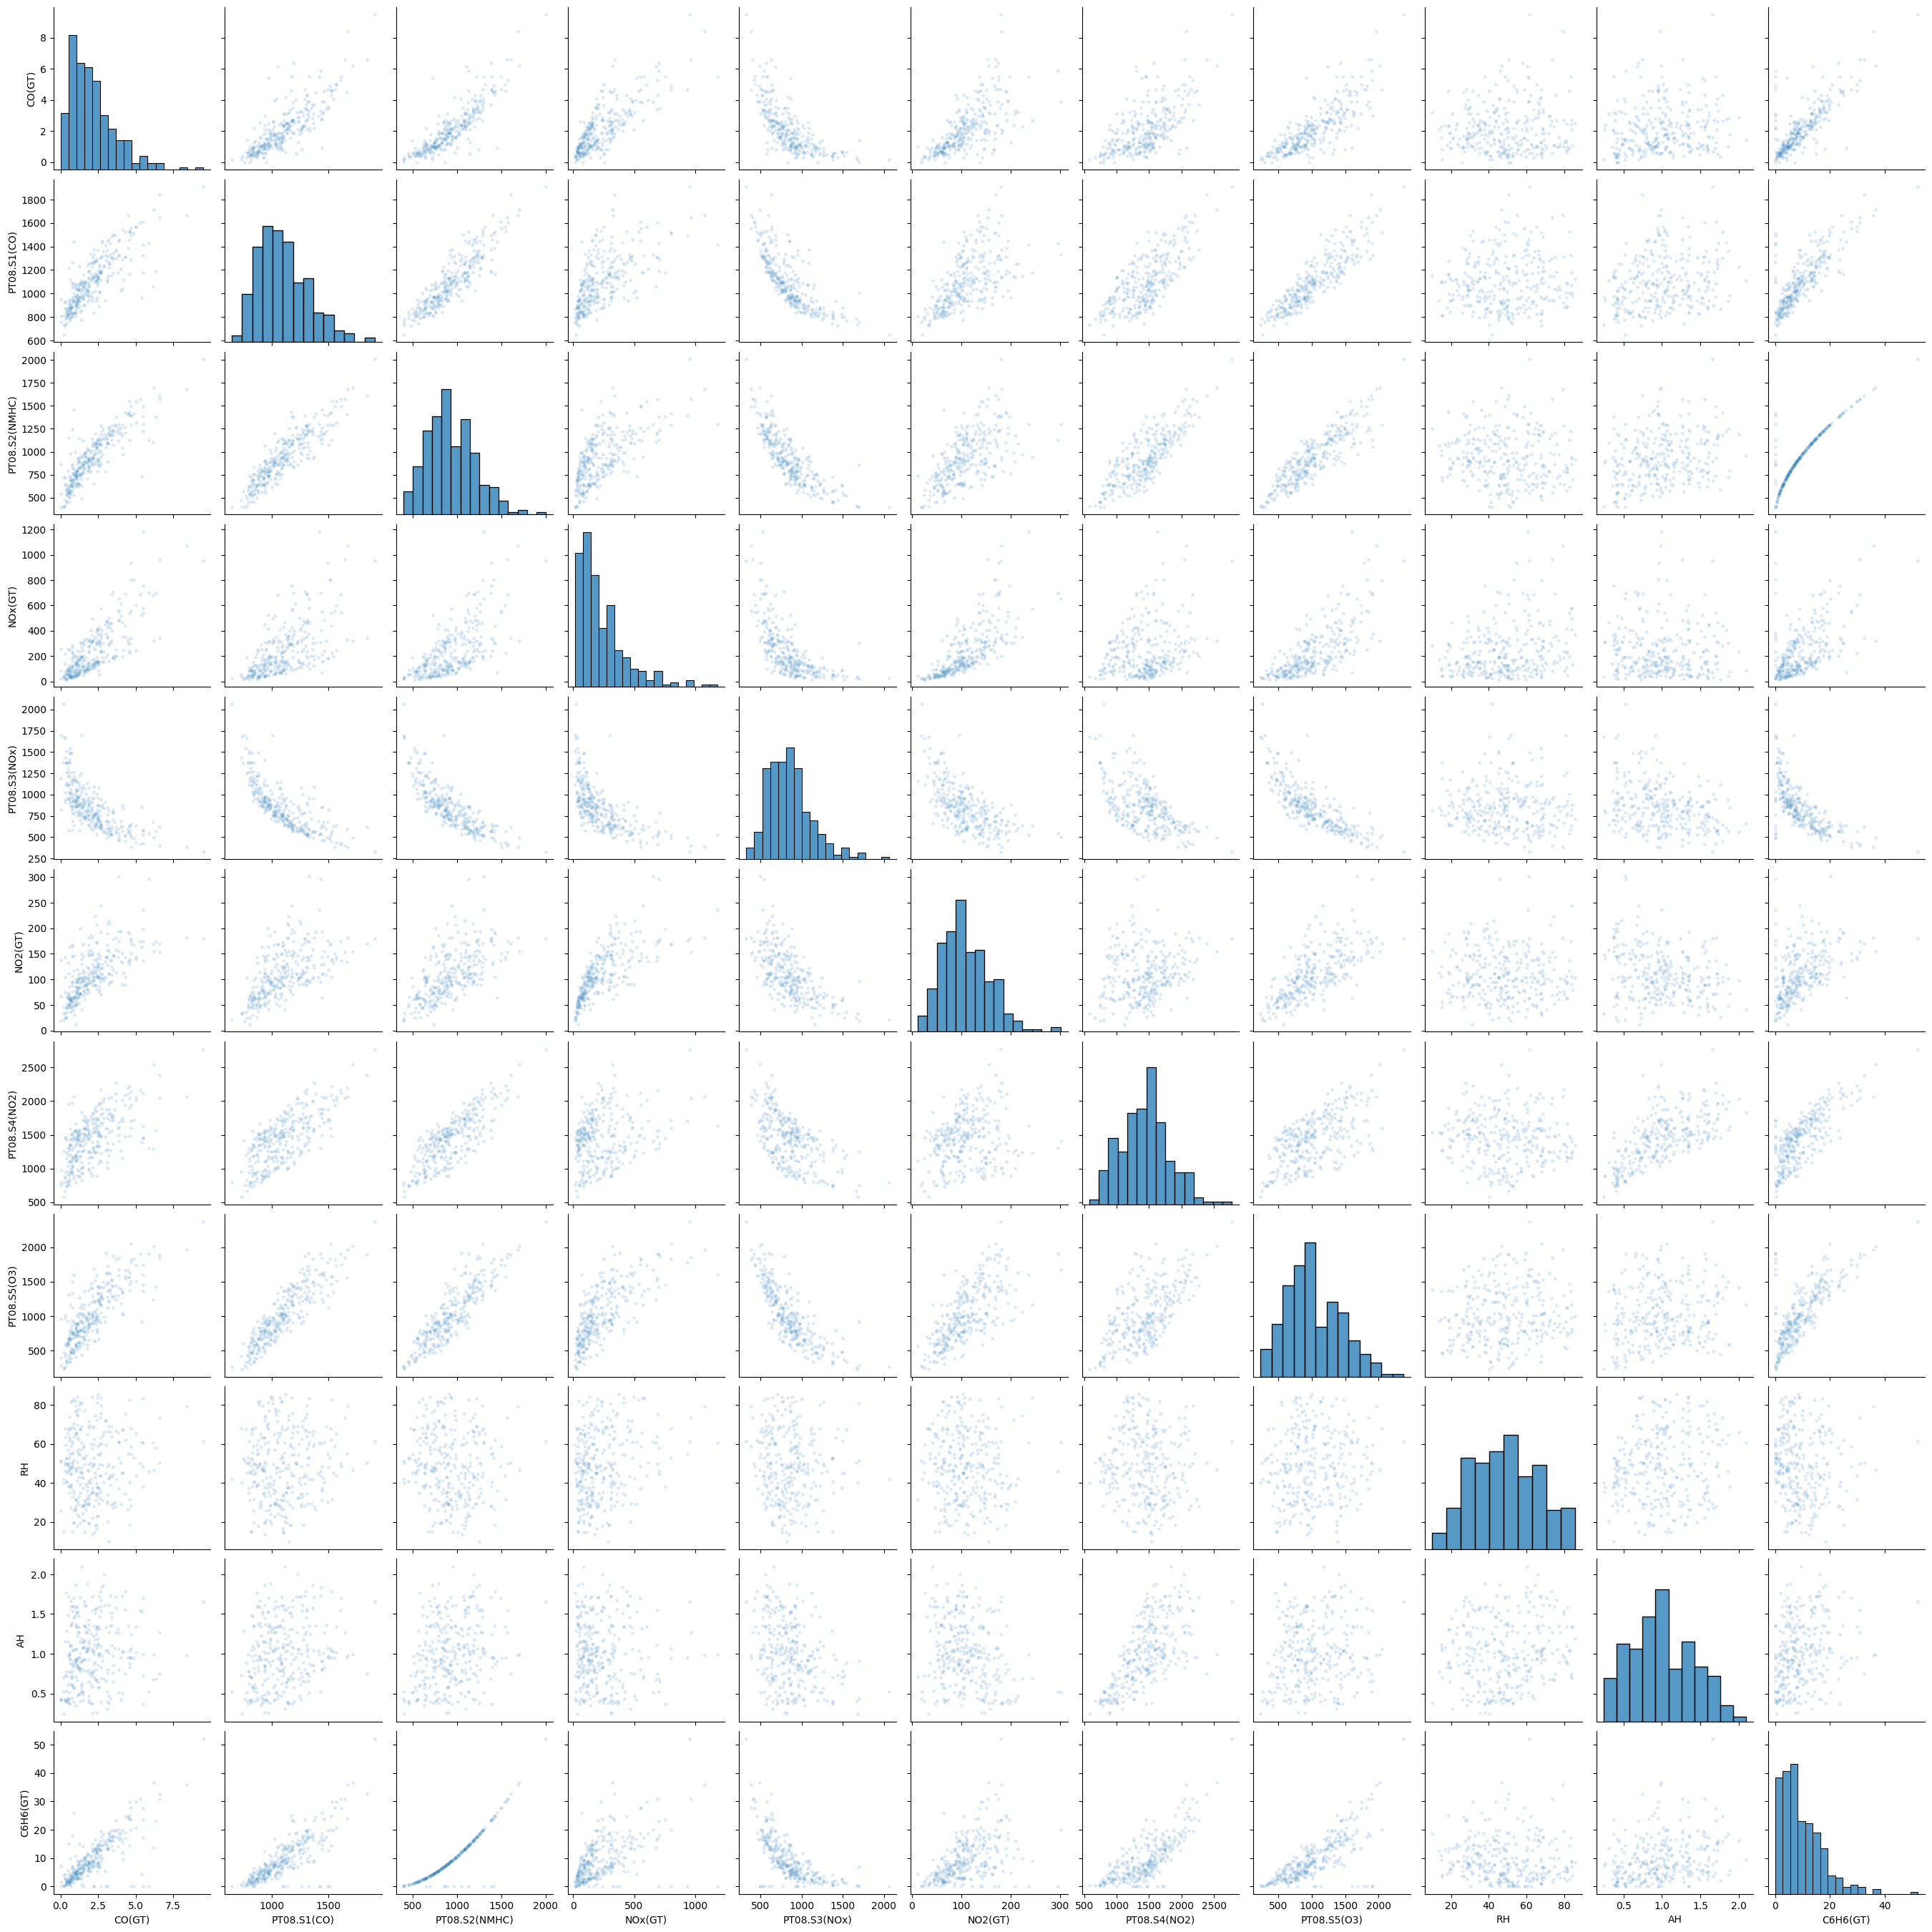

In [11]:
# 상관관계는 샘플링해서 가볍게 확인
sample_df = df.sample(min(len(df), 300), random_state=42)

sns.pairplot(
    sample_df,
    diag_kind='hist',
    plot_kws={'alpha': 0.15, 's': 12}
)
plt.show()

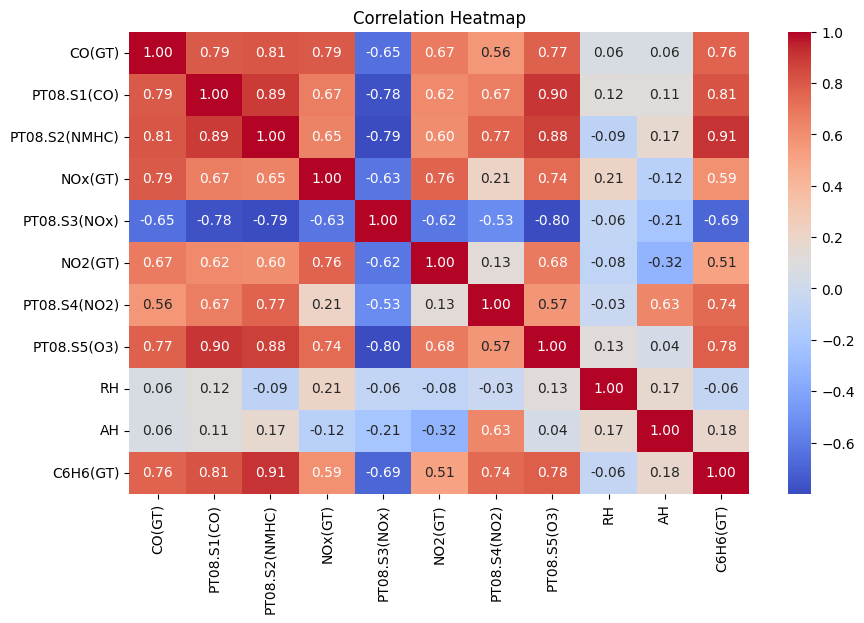

In [12]:
# 상관계수 히트맵
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**모델 학습과 피처 중요도 확인**

- 타깃: `CO(GT)`
- 피처: `CO(GT)`를 제외한 나머지 변수

In [13]:
# 학습 데이터 준비
X = df.drop(columns=['CO(GT)'])
y = df['CO(GT)']

print(X.shape, y.shape)

(9357, 10) (9357,)


In [14]:
# 학습 / 테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)

(7485, 10) (1872, 10)


In [15]:
# 랜덤 포레스트 회귀 모델 학습
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
# 예측 및 성능 평가
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f'MAE (Mean Absolute Error): {mae:.4f}')

MAE (Mean Absolute Error): 0.3007


In [21]:
#특징 중요도 출력
model.feature_importances_

array([0.06129058, 0.52140591, 0.2074758 , 0.01823665, 0.04154604,
       0.02084693, 0.01644585, 0.01540568, 0.02524844, 0.07209811])

In [18]:
# 피처 중요도 확인
feat_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_importances

PT08.S2(NMHC)    0.521406
NOx(GT)          0.207476
C6H6(GT)         0.072098
PT08.S1(CO)      0.061291
NO2(GT)          0.041546
AH               0.025248
PT08.S4(NO2)     0.020847
PT08.S3(NOx)     0.018237
PT08.S5(O3)      0.016446
RH               0.015406
dtype: float64

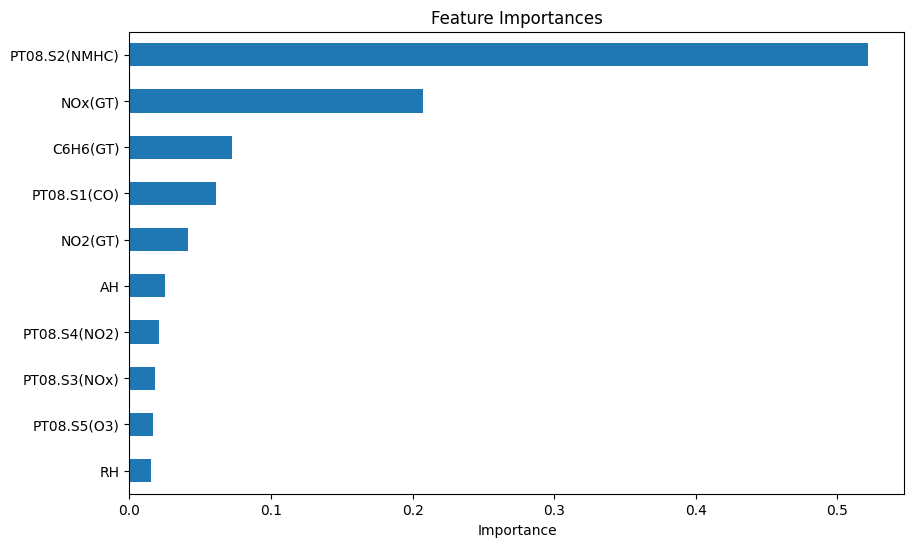

In [19]:
# 피처 중요도 시각화
plt.figure(figsize=(10, 6))
feat_importances.sort_values().plot(kind='barh')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()

In [22]:
# 중요 피처만 선택
selector = SelectFromModel(model, threshold='median', prefit=True)
selected_features = X.columns[selector.get_support()].tolist()

print('선택된 피처 수:', len(selected_features))
selected_features

선택된 피처 수: 5


['PT08.S1(CO)', 'PT08.S2(NMHC)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)']